In [1]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision 
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [2]:
train_data = datasets.FashionMNIST(
  root='data',
  train=True,
  download=True,
  transform=ToTensor(),
  target_transform=None,
)
test_data = datasets.FashionMNIST(
  root='data',
  train=False,
  download=True,
  transform=ToTensor(),
  target_transform=None,
)

100%|██████████| 26.4M/26.4M [00:13<00:00, 2.01MB/s]


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 1.57MB/s]


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.22MB/s]


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



In [10]:
image, label = train_data[0]
label

9

In [11]:
image.shape

torch.Size([1, 28, 28])

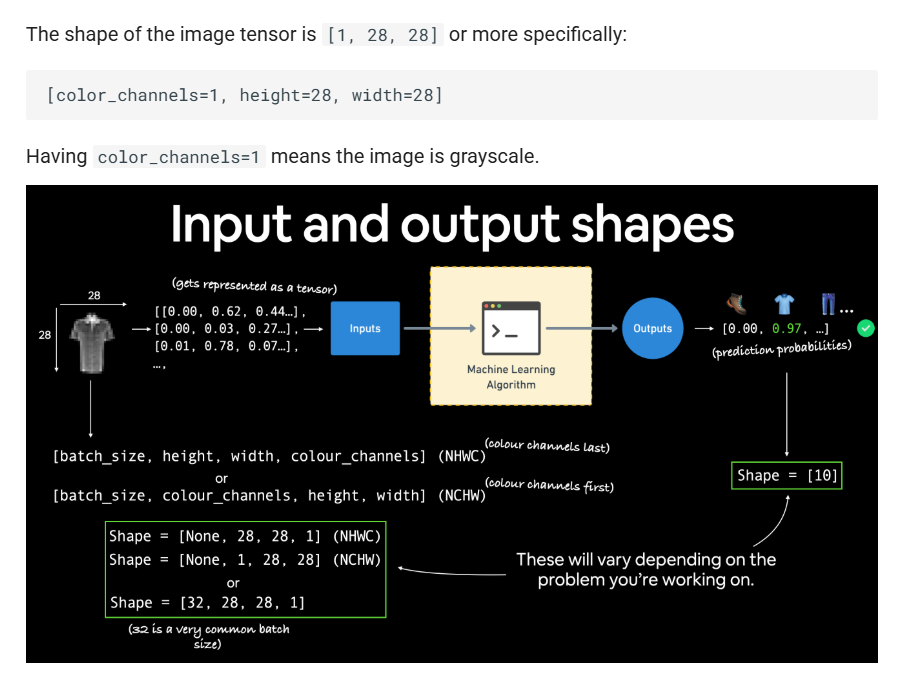

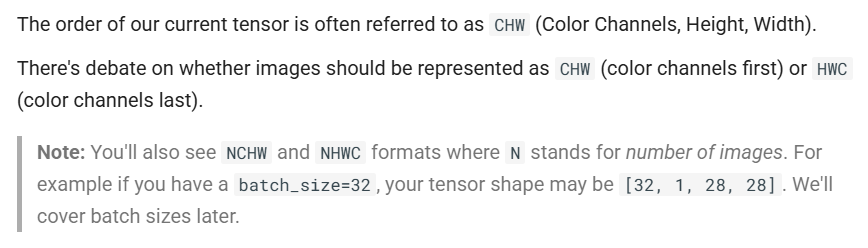

In [15]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [16]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

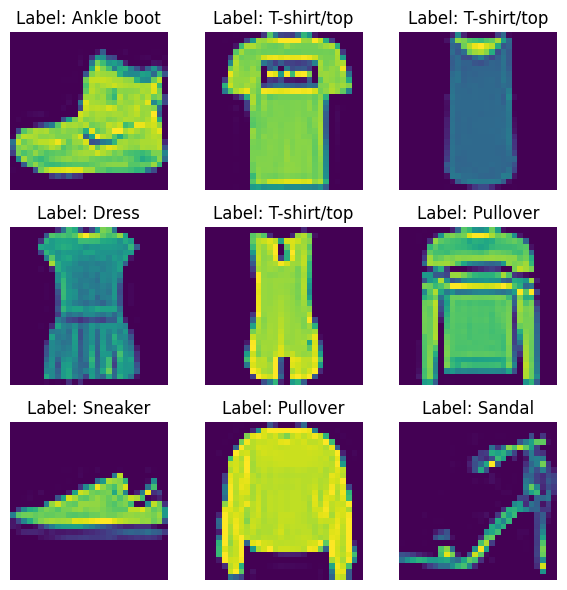

In [39]:
import matplotlib.pyplot as plt

width, height = 3, 3

fig, axes = plt.subplots(width, height, figsize=(6, 6))  # Create a 2x2 grid of subplots

for i in range(width):
  for j in range(height):
    image, label = train_data[width * i + j]  # Load data
    ax = axes[i, j]  # Select subplot
    ax.imshow(image.squeeze())  # Use colormap for better visualization
    ax.set_title(f"Label: {class_names[label]}")  # Set title
    ax.axis("off")  # Hide axes for cleaner output

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

In [40]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_data_loader = DataLoader(
  train_data,
  batch_size=BATCH_SIZE,
  shuffle=True,
)
test_data_loader = DataLoader(
  test_data,
  batch_size=BATCH_SIZE,
  shuffle=False,
)

## building a model

In [43]:
torch.manual_seed(42)

In [64]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [120]:
class FashionModel(nn.Module):
  def __init__(self, input_shape):
    super().__init__()
    self.flatten_layer = nn.Flatten()
    self.layer_1 = nn.Linear(in_features= input_shape, out_features=24)
    self.layer_3 = nn.Linear(in_features= 24 , out_features=10)
    
  def forward(self, x):
    return self.layer_3(self.layer_1(self.flatten_layer(x)))
  
model_0 = FashionModel(input_shape=28*28).to('cpu')

In [121]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
  params=model_0.parameters(),
  lr=0.1,
)

In [122]:
from timeit import default_timer as timer 

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [123]:
# Import tqdm for progress bar
from tqdm.auto import notebook_tqdm
from sklearn.metrics import f1_score

epochs = 3

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

for epoch in notebook_tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  
  train_loss = 0
  for batch, (X, y) in enumerate(train_data_loader):
    model_0.train()

    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if batch % 500 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_data_loader.dataset)} samples")
  train_loss /= len(train_data_loader)

  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_data_loader:
      test_pred = model_0(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += f1_score(y.cpu().numpy(), test_pred.argmax(dim=1).cpu().numpy(), average="macro")
    test_loss /= len(test_data_loader)
    test_acc /= len(test_data_loader)
  ## Print out what's happening
  print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test f1: {test_acc:.2f}%\n")

# Calculate training time      
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))
        

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples


 33%|███▎      | 1/3 [00:11<00:22, 11.48s/it]


Train loss: 0.58251 | Test loss: 0.50058, Test f1: 0.79%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples


 67%|██████▋   | 2/3 [00:22<00:11, 11.15s/it]


Train loss: 0.47493 | Test loss: 0.48172, Test f1: 0.80%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples


100%|██████████| 3/3 [00:33<00:00, 11.26s/it]


Train loss: 0.45420 | Test loss: 0.47728, Test f1: 0.80%

Train time on cpu: 33.783 seconds


In [124]:
torch.manual_seed(42)
def eval_model(
  model: torch.nn.Module, 
  data_loader: torch.utils.data.DataLoader, 
  loss_fn: torch.nn.Module):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      # Make predictions with the model
      y_pred = model(X)
      
      # Accumulate the loss and accuracy values per batch
      loss += loss_fn(y_pred, y)
      acc += f1_score(y.cpu().numpy(), y_pred.argmax(dim=1).cpu().numpy(), average='macro')
    # Scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)
  return {
    "model_name": model.__class__.__name__, # only works when model was created with a class
    "model_loss": loss.item(),
    "model_acc": acc
  }

In [125]:
model_0_results = eval_model(model_0, test_data_loader, loss_fn)
model_0_results

{'model_name': 'FashionModel',
 'model_loss': 0.47728079557418823,
 'model_acc': 0.8008170119200314}

# agnostic model

In [98]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [108]:
def f1_modified(y_true, y_pred) -> float:
  return f1_score(y_true.cpu().numpy(), y_pred.argmax(dim=1).cpu().numpy(), average='macro')

In [137]:
class FachionModelV2(nn.Module):
  def __init__(self, input_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=input_shape, out_features=12),
      # nn.ReLU(),
      nn.Linear(in_features=12, out_features=10),
    )
  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)
model_1 = FachionModelV2(784).to(device)
model_1

FachionModelV2(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=12, bias=True)
    (2): Linear(in_features=12, out_features=10, bias=True)
  )
)

In [138]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
  params=model_1.parameters(),
  lr=0.1,
)

In [109]:
def train(
  model: torch.nn.Module,
  data_loader: torch.utils.data.DataLoader,
  loss_fn: torch.nn.Module,
  optimizer: torch.optim.Optimizer,
  accuracy_fn,
  device: torch.device = device
):
  train_loss, train_f1 = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_f1 += accuracy_fn(y, y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  # Calculate loss and accuracy per epoch and print out what's happening
  train_loss /= len(data_loader)
  train_f1 /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_f1:.2f}%")

In [112]:
def test(
  data_loader: torch.utils.data.DataLoader,
  model: torch.nn.Module,
  loss_fn: torch.nn.Module,
  accuracy_fn,
  device: torch.device = device
):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred)
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [139]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in notebook_tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train(data_loader=train_data_loader, 
        model=model_1, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=f1_modified
    )
    test(data_loader=test_data_loader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=f1_modified
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.59151 | Train accuracy: 0.75%


 33%|███▎      | 1/3 [00:18<00:37, 18.60s/it]

Test loss: 0.51240 | Test accuracy: 0.79%

Epoch: 1
---------
Train loss: 0.47730 | Train accuracy: 0.80%


 67%|██████▋   | 2/3 [00:36<00:18, 18.39s/it]

Test loss: 0.48575 | Test accuracy: 0.80%

Epoch: 2
---------
Train loss: 0.45565 | Train accuracy: 0.81%


100%|██████████| 3/3 [00:55<00:00, 18.42s/it]

Test loss: 0.47734 | Test accuracy: 0.80%

Train time on cuda: 55.272 seconds


## CNN

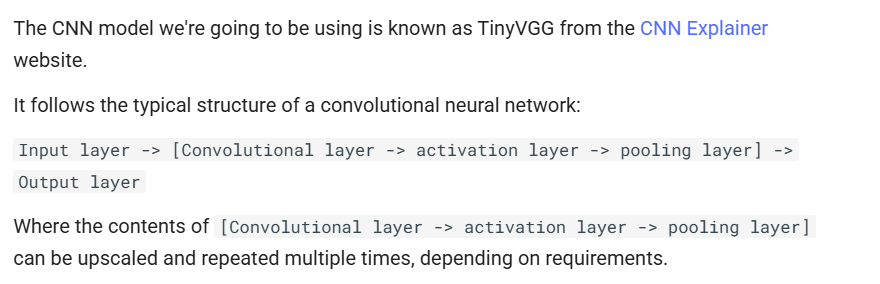

In [140]:
class FashionModelCNN(nn.Module):
  def __init__(self, input_shape):
    super().__init__()
    self.block_1 = nn.Sequential(
      nn.Conv2d(
        in_channels=input_shape,
        out_channels=12,
        kernel_size=3,
        stride=1,
        padding=1,
      ),
      nn.ReLU(),
      nn.Conv2d(
        in_channels=12, 
        out_channels=12,
        kernel_size=3,
        stride=1,
        padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2) # default stride value is same as kernel_size
    )
    self.block_2 = nn.Sequential(
      nn.Conv2d(12, 12, 3, padding=1),
      nn.ReLU(),
      nn.Conv2d(12, 12, 3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=12*7*7, out_features=10)
    )
    
  def forward(self, x: torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x
    

In [141]:
torch.manual_seed(42)
model_2 = FashionModelCNN(
  input_shape=1, 
).to(device)
model_2

FashionModelCNN(
  (block_1): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=588, out_features=10, bias=True)
  )
)

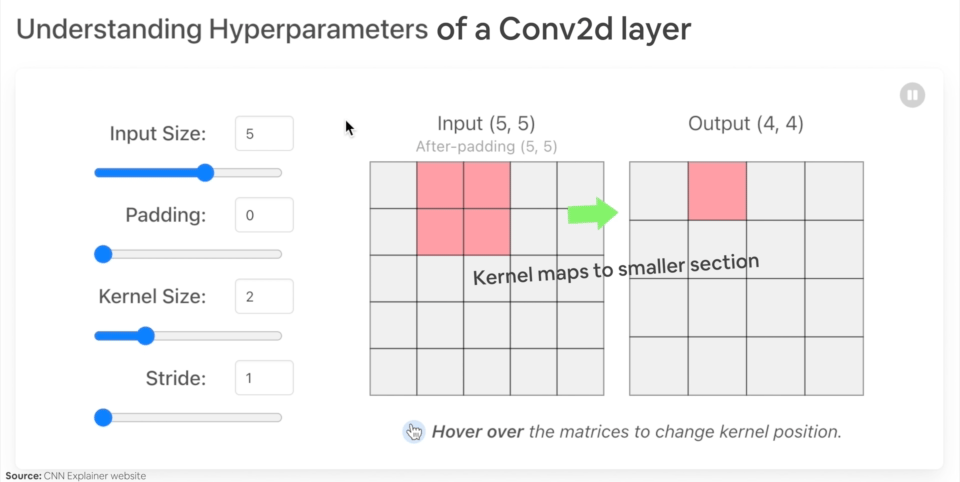

In [142]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
  params = model_2.parameters(),
  lr=0.1,
)

In [147]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

epochs = 3
for epoch in notebook_tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train(data_loader=train_data_loader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=f1_modified,
  )
  test(data_loader=test_data_loader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=f1_modified,
  )
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.27700 | Train accuracy: 0.88%


 33%|███▎      | 1/3 [00:17<00:34, 17.20s/it]

Test loss: 0.30486 | Test accuracy: 0.86%

Epoch: 1
---------
Train loss: 0.26726 | Train accuracy: 0.88%


 67%|██████▋   | 2/3 [00:34<00:17, 17.29s/it]

Test loss: 0.29482 | Test accuracy: 0.87%

Epoch: 2
---------
Train loss: 0.25870 | Train accuracy: 0.88%


100%|██████████| 3/3 [00:51<00:00, 17.04s/it]

Test loss: 0.29222 | Test accuracy: 0.87%

Train time on cuda: 51.132 seconds
